In [1]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages.utils import trim_messages,count_tokens_approximately

In [2]:
load_dotenv()

True

In [3]:
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


In [4]:
MAX_TOKENS = 150

In [5]:
def call_model(state: MessagesState):
    
    # Trim conversation history -> last N messages that fit within the token budget
    messages = trim_messages(
        state["messages"],
        strategy="last",                      
        token_counter=count_tokens_approximately,
        max_tokens=MAX_TOKENS
    )

    print('Current Token Count ->', count_tokens_approximately(messages=messages))

    for message in messages:
        print(message.content)

    response = model.invoke(messages)

    return {"messages": [response]}

In [6]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [7]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

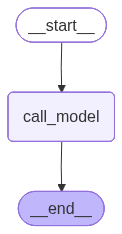

In [8]:
graph

In [9]:
config = {"configurable": {"thread_id": "chat-1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Hi, my name is Nitish."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 10
Hi, my name is Nitish.


'Hi Nitish! Nice to meet you.\n\nHow can I help you today?'

In [10]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "I am learning LangGraph."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 39
Hi, my name is Nitish.
Hi Nitish! Nice to meet you.

How can I help you today?
I am learning LangGraph.


"That's fantastic! LangGraph is a powerful and flexible library for building complex, stateful LLM applications and agents. It really shines when you need to orchestrate multiple steps, tools, and decision points.\n\nWhat specifically are you working on or curious about? Are there any particular concepts, examples, or challenges you'd like to discuss?\n\nFor instance, we could talk about:\n*   **Core concepts:** Nodes, edges, state, graph execution.\n*   **Building your first graph:** A simple sequential chain or a basic agent.\n*   **Conditional routing:** How to make your graph choose different paths.\n*   **Tool integration:** Using LangGraph to manage tool calling and responses.\n*   **Human-in-the-loop:** Incorporating human feedback or decisions.\n*   **Debugging:** Strategies for understanding what's happening in your graph.\n*   **Specific use cases:** Like a research agent, a customer support bot, or a data processing workflow.\n\nJust let me know how I can assist you on your 

In [11]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "Can you explain short term memory?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 13
Can you explain short term memory?


'Short-term memory (STM) is a system for temporarily storing and managing information. It\'s the information you are currently aware of or actively thinking about at any given moment. Think of it as your brain\'s immediate "scratchpad" or "mental workspace."\n\nHere are its key characteristics:\n\n1.  **Limited Capacity:** STM can only hold a small amount of information at one time. A classic finding by George Miller (1956) suggests this capacity is roughly **7 ± 2 items** (or "chunks" of information). For example, you can usually remember about 5-9 digits, words, or simple ideas.\n2.  **Limited Duration:** Information in STM doesn\'t last long without active rehearsal. It typically fades within **15 to 30 seconds** if you don\'t make an effort to keep it in mind (e.g., by repeating it).\n3.  **Active and Conscious:** STM is where conscious processing happens. It\'s what you are "attending to" right now.\n4.  **Gateway to Long-Term Memory:** Information often needs to pass through STM 

In [12]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "What is my name?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 8
What is my name?


"I do not know your name. As an AI, I don't have access to personal information about you or any memory of who you are. My interactions are anonymous."

In [13]:
for item in graph.get_state({"configurable": {"thread_id": "chat-1"}}).values['messages']:
    print(item.content)
    print('-'*120)

Hi, my name is Nitish.
------------------------------------------------------------------------------------------------------------------------
Hi Nitish! Nice to meet you.

How can I help you today?
------------------------------------------------------------------------------------------------------------------------
I am learning LangGraph.
------------------------------------------------------------------------------------------------------------------------
That's fantastic! LangGraph is a powerful and flexible library for building complex, stateful LLM applications and agents. It really shines when you need to orchestrate multiple steps, tools, and decision points.

What specifically are you working on or curious about? Are there any particular concepts, examples, or challenges you'd like to discuss?

For instance, we could talk about:
*   **Core concepts:** Nodes, edges, state, graph execution.
*   **Building your first graph:** A simple sequential chain or a basic agent.
*   **